# Quantum benchmark paper summary

This notebook consolidates the **Sampler** and **Estimator** results requested for the paper into a single analysis.

### Data provenance and scope

- **Sampler success:** merged normalized results from the shared Sampler summary notebook, including the later RND runs.
- **Sampler QPU time:** loaded directly from the available `results/*/sampler_benchmark_summary.csv` files. An embedded fallback is retained so the notebook remains portable. Q-CTRL summary rows are expanded by their `algorithms` field, which provides QPU times for BV, QPE, and GHZ.
- **Estimator:** the 8-layer, full-chain TFIM results at \(n=25,50,75\), with QPU times from the shared estimator summary.
- Circuit examples are generated with **Qiskit**, using the logical constructors from the benchmark workflows rather than manually drawn schematics.
- The separate **16-layer full-chain** result set is not mixed into the estimator figures because it does not contain QESEM and uses a different ideal MPS reference.
- IBM ZNE is not shown because it was disabled in the shared estimator run and no ZNE results were present.

### Metric definitions

- **Sampler success rate:** probability assigned to the correct output. For GHZ, this is the combined probability of the two valid outputs \(0\ldots0\) and \(1\ldots1\).
- **Estimator normalized success:** a bounded closeness score relative to the ideal MPS expectation value,
  \[
  S_O = 100\left(1-\frac{|\langle O\rangle_{\mathrm{method}}-\langle O\rangle_{\mathrm{MPS}}|}{2}\right).
  \]
  It is an agreement score, not a sampling probability.
- **TFIM Hamiltonian normalized success:** the combined score
  \[
  S_H=\frac{S_X+S_{ZZ}}{2},
  \]
  which summarizes agreement across the two full-chain TFIM Hamiltonian components used in this benchmark.


In [1]:

from pathlib import Path
from fractions import Fraction
from math import pi
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import circuit_drawer

OUTPUT_DIR = Path("results/paper_summary")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Remove the obsolete combined Sampler-circuit panel from earlier notebook versions.
obsolete_combined_circuit = FIGURE_DIR / "sampler_circuit_examples_qiskit.png"
if obsolete_combined_circuit.exists():
    obsolete_combined_circuit.unlink()


# Remove the obsolete combined TFIM expected-value panel.
obsolete_combined_expected_values = (
    FIGURE_DIR / "estimator_full_chain_expected_values_X_ZZ.png"
)
if obsolete_combined_expected_values.exists():
    obsolete_combined_expected_values.unlink()

# Bright but restrained, colorblind-aware paper palette.
COLORS = {
    "Ideal MPS": "#6B7280",
    "IBM raw": "#3B73B9",
    "IBM measurement twirling": "#3E9651",
    "IBM TREX + twirling": "#3E9651",
    "Q-CTRL": "#7A5AA6",
    "QESEM": "#E58A2B",
}

SAMPLER_PROVIDER_ORDER = [
    "IBM raw",
    "IBM measurement twirling",
    "Q-CTRL",
]

ESTIMATOR_PROVIDER_ORDER = [
    "IBM raw",
    "IBM TREX + twirling",
    "Q-CTRL",
    "QESEM",
]

EXPECTATION_PROVIDER_ORDER = [
    "Ideal MPS",
    *ESTIMATOR_PROVIDER_ORDER,
]

# Qiskit circuit-drawer colors chosen to match the paper figures.
QISKIT_CIRCUIT_STYLE = {
    "name": "iqp",
    "backgroundcolor": "#FFFFFF",
    "linecolor": "#4B5563",
    "textcolor": "#1F2937",
    "gatetextcolor": "#FFFFFF",
    "displaycolor": {
        "h": ["#3B73B9", "#FFFFFF"],
        "x": ["#315F93", "#FFFFFF"],
        "cx": ["#3B73B9", "#FFFFFF"],
        "cz": ["#3E9651", "#FFFFFF"],
        "cp": ["#7A5AA6", "#FFFFFF"],
        "p": ["#7A5AA6", "#FFFFFF"],
        "rx": ["#E58A2B", "#FFFFFF"],
        "rz": ["#7A5AA6", "#FFFFFF"],
        "rzz": ["#3E9651", "#FFFFFF"],
        "sx": ["#7A5AA6", "#FFFFFF"],
        "sxdg": ["#674A91", "#FFFFFF"],
        "swap": ["#3B73B9", "#FFFFFF"],
        "measure": ["#D1D5DB", "#1F2937"],
        "barrier": ["#E5E7EB", "#4B5563"],
    },
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved: {path}")
    return path


## Benchmark data, live summary loading, and validation

In [2]:

SAMPLER_RECORDS = json.loads(r"""[{"provider":"IBM measurement twirling","algorithm":"BV","n":25,"success_probability":0.554657},{"provider":"IBM raw","algorithm":"BV","n":25,"success_probability":0.536896},{"provider":"Q-CTRL","algorithm":"BV","n":25,"success_probability":0.79776},{"provider":"IBM measurement twirling","algorithm":"BV","n":50,"success_probability":0.085602},{"provider":"IBM raw","algorithm":"BV","n":50,"success_probability":0.099121},{"provider":"Q-CTRL","algorithm":"BV","n":50,"success_probability":0.391998},{"provider":"IBM measurement twirling","algorithm":"BV","n":75,"success_probability":0.02829},{"provider":"IBM raw","algorithm":"BV","n":75,"success_probability":0.032776},{"provider":"Q-CTRL","algorithm":"BV","n":75,"success_probability":0.351135},{"provider":"IBM measurement twirling","algorithm":"GHZ","n":25,"success_probability":0.651489},{"provider":"IBM raw","algorithm":"GHZ","n":25,"success_probability":0.659119},{"provider":"Q-CTRL","algorithm":"GHZ","n":25,"success_probability":0.744751},{"provider":"IBM measurement twirling","algorithm":"GHZ","n":50,"success_probability":0.350006},{"provider":"IBM raw","algorithm":"GHZ","n":50,"success_probability":0.387878},{"provider":"Q-CTRL","algorithm":"GHZ","n":50,"success_probability":0.456512},{"provider":"IBM measurement twirling","algorithm":"QPE","n":10,"success_probability":0.64215087890625},{"provider":"IBM raw","algorithm":"QPE","n":10,"success_probability":0.654693603515625},{"provider":"Q-CTRL","algorithm":"QPE","n":10,"success_probability":0.779907},{"provider":"IBM measurement twirling","algorithm":"QPE","n":20,"success_probability":9.2e-05},{"provider":"IBM raw","algorithm":"QPE","n":20,"success_probability":0.000366},{"provider":"Q-CTRL","algorithm":"QPE","n":20,"success_probability":0.376251},{"provider":"IBM measurement twirling","algorithm":"QPE","n":30,"success_probability":0.0},{"provider":"IBM raw","algorithm":"QPE","n":30,"success_probability":0.0},{"provider":"Q-CTRL","algorithm":"QPE","n":30,"success_probability":0.126862},{"provider":"IBM measurement twirling","algorithm":"RND","n":25,"success_probability":0.616058},{"provider":"IBM raw","algorithm":"RND","n":25,"success_probability":0.635193},{"provider":"Q-CTRL","algorithm":"RND","n":25,"success_probability":0.934753},{"provider":"IBM measurement twirling","algorithm":"RND","n":50,"success_probability":0.292938},{"provider":"IBM raw","algorithm":"RND","n":50,"success_probability":0.299988},{"provider":"Q-CTRL","algorithm":"RND","n":50,"success_probability":0.87851},{"provider":"IBM measurement twirling","algorithm":"RND","n":75,"success_probability":0.161835},{"provider":"IBM raw","algorithm":"RND","n":75,"success_probability":0.179626},{"provider":"Q-CTRL","algorithm":"RND","n":75,"success_probability":0.841248},{"provider":"IBM measurement twirling","algorithm":"RND","n":100,"success_probability":0.082642},{"provider":"IBM raw","algorithm":"RND","n":100,"success_probability":0.09137},{"provider":"Q-CTRL","algorithm":"RND","n":100,"success_probability":0.764526}]""")
SAMPLER_QPU_FALLBACK_RECORDS = json.loads(r"""[{"provider":"IBM measurement twirling","algorithm":"BV","n":25,"qpu_seconds":19.308443,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"BV","n":25,"qpu_seconds":23.289643,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"BV","n":50,"qpu_seconds":19.977826,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"BV","n":50,"qpu_seconds":24.022775,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"BV","n":75,"qpu_seconds":22.800634,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"BV","n":75,"qpu_seconds":27.206817,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"GHZ","n":25,"qpu_seconds":19.308443,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"GHZ","n":25,"qpu_seconds":23.289643,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"GHZ","n":50,"qpu_seconds":19.977826,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"GHZ","n":50,"qpu_seconds":24.022775,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"QPE","n":10,"qpu_seconds":19.832527,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"QPE","n":10,"qpu_seconds":23.870983,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"QPE","n":20,"qpu_seconds":28.293896,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"QPE","n":20,"qpu_seconds":35.586838,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"QPE","n":30,"qpu_seconds":28.575457,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"QPE","n":30,"qpu_seconds":35.969313,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"RND","n":25,"qpu_seconds":10.322271,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"RND","n":25,"qpu_seconds":10.328002,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"RND","n":50,"qpu_seconds":10.322271,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"RND","n":50,"qpu_seconds":10.328002,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"RND","n":75,"qpu_seconds":10.322271,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"RND","n":75,"qpu_seconds":10.328002,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM measurement twirling","algorithm":"RND","n":100,"qpu_seconds":10.322271,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"IBM raw","algorithm":"RND","n":100,"qpu_seconds":10.328002,"qpu_time_source":"sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"QPE","n":10,"qpu_seconds":20.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"QPE","n":20,"qpu_seconds":20.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"BV","n":25,"qpu_seconds":28.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"GHZ","n":25,"qpu_seconds":28.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"QPE","n":30,"qpu_seconds":20.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"BV","n":50,"qpu_seconds":28.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"GHZ","n":50,"qpu_seconds":28.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"},{"provider":"Q-CTRL","algorithm":"BV","n":75,"qpu_seconds":29.0,"qpu_time_source":"results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"}]""")
ESTIMATOR_RECORDS = json.loads(r"""[{"provider":"IBM TREX + twirling","n":25,"observable":"MX_full","expectation_value":0.5668679,"std":0.001733,"ideal":0.6606342,"absolute_error":0.09376629},{"provider":"IBM raw","n":25,"observable":"MX_full","expectation_value":0.4927759,"std":0.00095,"ideal":0.6606342,"absolute_error":0.1678583},{"provider":"Q-CTRL","n":25,"observable":"MX_full","expectation_value":0.6262842,"std":0.155716,"ideal":0.6606342,"absolute_error":0.03435003},{"provider":"QESEM","n":25,"observable":"MX_full","expectation_value":0.6798874,"std":0.021303,"ideal":0.6606342,"absolute_error":0.01925318},{"provider":"IBM TREX + twirling","n":50,"observable":"MX_full","expectation_value":0.5559542,"std":0.001107,"ideal":0.6519781,"absolute_error":0.09602386},{"provider":"IBM raw","n":50,"observable":"MX_full","expectation_value":0.5061536,"std":0.000669,"ideal":0.6519781,"absolute_error":0.1458245},{"provider":"Q-CTRL","n":50,"observable":"MX_full","expectation_value":0.6100854,"std":0.111941,"ideal":0.6519781,"absolute_error":0.0418926},{"provider":"QESEM","n":50,"observable":"MX_full","expectation_value":0.6148756,"std":0.017169,"ideal":0.6519781,"absolute_error":0.03710244},{"provider":"IBM TREX + twirling","n":75,"observable":"MX_full","expectation_value":0.5310911,"std":0.001008,"ideal":0.6490927,"absolute_error":0.1180015},{"provider":"IBM raw","n":75,"observable":"MX_full","expectation_value":0.5176994,"std":0.000542,"ideal":0.6490927,"absolute_error":0.1313933},{"provider":"Q-CTRL","n":75,"observable":"MX_full","expectation_value":0.6126652,"std":0.091156,"ideal":0.6490927,"absolute_error":0.03642746},{"provider":"QESEM","n":75,"observable":"MX_full","expectation_value":0.621976,"std":0.025745,"ideal":0.6490927,"absolute_error":0.02711666},{"provider":"IBM TREX + twirling","n":25,"observable":"ZZ_full","expectation_value":0.3405556,"std":0.001915,"ideal":0.3886767,"absolute_error":0.04812114},{"provider":"IBM raw","n":25,"observable":"ZZ_full","expectation_value":0.391861,"std":0.001031,"ideal":0.3886767,"absolute_error":0.003184222},{"provider":"Q-CTRL","n":25,"observable":"ZZ_full","expectation_value":0.3672434,"std":0.189763,"ideal":0.3886767,"absolute_error":0.02143329},{"provider":"QESEM","n":25,"observable":"ZZ_full","expectation_value":0.3959704,"std":0.017828,"ideal":0.3886767,"absolute_error":0.007293621},{"provider":"IBM TREX + twirling","n":50,"observable":"ZZ_full","expectation_value":0.3347108,"std":0.001276,"ideal":0.3909887,"absolute_error":0.0562779},{"provider":"IBM raw","n":50,"observable":"ZZ_full","expectation_value":0.372429,"std":0.000729,"ideal":0.3909887,"absolute_error":0.01855969},{"provider":"Q-CTRL","n":50,"observable":"ZZ_full","expectation_value":0.3744955,"std":0.132413,"ideal":0.3909887,"absolute_error":0.01649321},{"provider":"QESEM","n":50,"observable":"ZZ_full","expectation_value":0.4045955,"std":0.013295,"ideal":0.3909887,"absolute_error":0.01360673},{"provider":"IBM TREX + twirling","n":75,"observable":"ZZ_full","expectation_value":0.3198963,"std":0.000974,"ideal":0.3917386,"absolute_error":0.0718423},{"provider":"IBM raw","n":75,"observable":"ZZ_full","expectation_value":0.3289284,"std":0.000605,"ideal":0.3917386,"absolute_error":0.06281022},{"provider":"Q-CTRL","n":75,"observable":"ZZ_full","expectation_value":0.3714154,"std":0.107897,"ideal":0.3917386,"absolute_error":0.02032315},{"provider":"QESEM","n":75,"observable":"ZZ_full","expectation_value":0.3834356,"std":0.021601,"ideal":0.3917386,"absolute_error":0.008303002}]""")
ESTIMATOR_QPU_RECORDS = json.loads(r"""[{"provider":"IBM TREX + twirling","n":25,"qpu_seconds":28.0},{"provider":"IBM raw","n":25,"qpu_seconds":17.823486},{"provider":"Q-CTRL","n":25,"qpu_seconds":28.0},{"provider":"QESEM","n":25,"qpu_seconds":271.0},{"provider":"IBM TREX + twirling","n":50,"qpu_seconds":37.826296},{"provider":"IBM raw","n":50,"qpu_seconds":17.823486},{"provider":"Q-CTRL","n":50,"qpu_seconds":28.0},{"provider":"QESEM","n":50,"qpu_seconds":311.0},{"provider":"IBM TREX + twirling","n":75,"qpu_seconds":37.826296},{"provider":"IBM raw","n":75,"qpu_seconds":17.823486},{"provider":"Q-CTRL","n":75,"qpu_seconds":28.0},{"provider":"QESEM","n":75,"qpu_seconds":211.0}]""")

# Exact workload selections requested for the paper.
EXPECTED_SAMPLER_SIZES = {
    "GHZ": [25, 50],
    "QPE": [10, 20, 30],
    "BV": [25, 50, 75],
    "RND": [25, 50, 75, 100],
}

sampler_df = pd.DataFrame(SAMPLER_RECORDS)
sampler_df["success_rate_percent"] = 100.0 * sampler_df["success_probability"]

# Read QPU times directly from all available Sampler summary files.
# Each row may list several algorithms; the time is expanded to every
# listed algorithm so the corresponding paper panel can display it.
SAMPLER_QPU_SUMMARY_FILES = [
    Path("results/sampler_benchmark/sampler_benchmark_summary.csv"),
    Path("results/sampler_benchmark-QCTRL/sampler_benchmark_summary.csv"),
    Path("results/sampler_benchmark-QCTRL-RND/sampler_benchmark_summary.csv"),
]


def normalize_sampler_provider(value):
    text = str(value).strip()
    aliases = {
        "QCTRL": "Q-CTRL",
        "Q CTRL": "Q-CTRL",
        "IBM measurement twirl": "IBM measurement twirling",
    }
    return aliases.get(text, text)


def expand_sampler_qpu_summary(path, priority):
    summary = pd.read_csv(path)
    required = {"provider", "n", "qpu_seconds", "algorithms"}
    missing = required.difference(summary.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    rows = []
    for _, row in summary.iterrows():
        qpu_seconds = pd.to_numeric(row.get("qpu_seconds"), errors="coerce")
        if not np.isfinite(qpu_seconds):
            continue

        algorithms = [
            item.strip()
            for item in str(row.get("algorithms", "")).split(",")
            if item.strip()
        ]
        for algorithm in algorithms:
            rows.append({
                "provider": normalize_sampler_provider(row["provider"]),
                "algorithm": algorithm,
                "n": int(row["n"]),
                "qpu_seconds": float(qpu_seconds),
                "qpu_time_source": str(path),
                "_source_priority": int(priority),
            })

    return pd.DataFrame(rows)


qpu_frames = []
embedded_qpu = pd.DataFrame(SAMPLER_QPU_FALLBACK_RECORDS)
embedded_qpu["_source_priority"] = 0
qpu_frames.append(embedded_qpu)

loaded_qpu_files = []
for priority, path in enumerate(SAMPLER_QPU_SUMMARY_FILES, start=1):
    if path.exists():
        expanded = expand_sampler_qpu_summary(path, priority)
        if not expanded.empty:
            qpu_frames.append(expanded)
        loaded_qpu_files.append(str(path))

sampler_qpu_df = pd.concat(qpu_frames, ignore_index=True, sort=False)
sampler_qpu_df["provider"] = sampler_qpu_df["provider"].map(normalize_sampler_provider)
sampler_qpu_df["n"] = pd.to_numeric(sampler_qpu_df["n"], errors="raise").astype(int)
sampler_qpu_df["qpu_seconds"] = pd.to_numeric(
    sampler_qpu_df["qpu_seconds"], errors="coerce"
)

# A real CSV row overrides the embedded fallback for the same provider/workload.
sampler_qpu_df = (
    sampler_qpu_df
    .sort_values("_source_priority")
    .drop_duplicates(subset=["provider", "algorithm", "n"], keep="last")
    .drop(columns="_source_priority")
)

# Keep only the exact workload sizes requested for the paper.
requested_pairs = {
    (algorithm, n)
    for algorithm, sizes in EXPECTED_SAMPLER_SIZES.items()
    for n in sizes
}
sampler_qpu_df = sampler_qpu_df.loc[
    sampler_qpu_df.apply(
        lambda row: (row["algorithm"], int(row["n"])) in requested_pairs,
        axis=1,
    )
].copy()

estimator_df = pd.DataFrame(ESTIMATOR_RECORDS)
estimator_df["closeness_percent"] = (
    100.0 * (1.0 - estimator_df["absolute_error"].clip(lower=0.0, upper=2.0) / 2.0)
).clip(lower=0.0, upper=100.0)
estimator_df["observable_label"] = estimator_df["observable"].map({
    "MX_full": "X",
    "ZZ_full": "ZZ",
})

estimator_qpu_df = pd.DataFrame(ESTIMATOR_QPU_RECORDS)

for algorithm, expected_sizes in EXPECTED_SAMPLER_SIZES.items():
    actual_sizes = sorted(
        sampler_df.loc[sampler_df["algorithm"].eq(algorithm), "n"].unique().tolist()
    )
    assert actual_sizes == expected_sizes, (
        f"{algorithm} sizes do not match the requested set: "
        f"expected {expected_sizes}, found {actual_sizes}"
    )

assert sorted(estimator_df["n"].unique().tolist()) == [25, 50, 75]
assert set(estimator_df["observable"]) == {"MX_full", "ZZ_full"}
assert set(estimator_df["provider"]) == set(ESTIMATOR_PROVIDER_ORDER)
assert set(estimator_qpu_df["provider"]) == set(ESTIMATOR_PROVIDER_ORDER)

# Q-CTRL QPU seconds exist for BV, QPE, and GHZ in the Q-CTRL benchmark
# summary. The RND Q-CTRL summary explicitly reports them as unavailable.
QPU_PROVIDERS_REQUIRED_BY_ALGORITHM = {
    "GHZ": ["IBM raw", "IBM measurement twirling", "Q-CTRL"],
    "QPE": ["IBM raw", "IBM measurement twirling", "Q-CTRL"],
    "BV": ["IBM raw", "IBM measurement twirling", "Q-CTRL"],
    "RND": ["IBM raw", "IBM measurement twirling"],
}

for algorithm, expected_sizes in EXPECTED_SAMPLER_SIZES.items():
    for provider in QPU_PROVIDERS_REQUIRED_BY_ALGORITHM[algorithm]:
        available_sizes = sorted(
            sampler_qpu_df.loc[
                sampler_qpu_df["algorithm"].eq(algorithm)
                & sampler_qpu_df["provider"].eq(provider)
                & sampler_qpu_df["qpu_seconds"].notna(),
                "n",
            ].unique().tolist()
        )
        assert available_sizes == expected_sizes, (
            f"Missing QPU-time values for {algorithm}, {provider}: "
            f"expected {expected_sizes}, found {available_sizes}"
        )

sampler_df.to_csv(OUTPUT_DIR / "sampler_paper_summary.csv", index=False)
sampler_qpu_df.to_csv(OUTPUT_DIR / "sampler_qpu_summary.csv", index=False)
estimator_df.to_csv(OUTPUT_DIR / "estimator_paper_summary.csv", index=False)
estimator_qpu_df.to_csv(OUTPUT_DIR / "estimator_qpu_summary.csv", index=False)

print("Sampler success rows:", len(sampler_df))
print("Sampler QPU-time rows:", len(sampler_qpu_df))
print("Live QPU summary files loaded:", loaded_qpu_files or "none; embedded fallback used")
print("Q-CTRL QPU rows used for BV, QPE, and GHZ:")
display(
    sampler_qpu_df.loc[
        sampler_qpu_df["provider"].eq("Q-CTRL")
        & sampler_qpu_df["algorithm"].isin(["BV", "QPE", "GHZ"])
    ]
    .sort_values(["algorithm", "n"])
    .reset_index(drop=True)
)
print("Validation passed.")


Sampler success rows: 36
Sampler QPU-time rows: 36
Live QPU summary files loaded: ['results\\sampler_benchmark\\sampler_benchmark_summary.csv', 'results\\sampler_benchmark-QCTRL\\sampler_benchmark_summary.csv', 'results\\sampler_benchmark-QCTRL-RND\\sampler_benchmark_summary.csv']
Q-CTRL QPU rows used for BV, QPE, and GHZ:


,provider,algorithm,n,qpu_seconds,qpu_time_source
0,Q-CTRL,BV,25,28.0,results/sampler_benchmark-QCTRL/sampler_benchm...
1,Q-CTRL,BV,50,28.0,results/sampler_benchmark-QCTRL/sampler_benchm...
2,Q-CTRL,BV,75,29.0,results/sampler_benchmark-QCTRL/sampler_benchm...
3,Q-CTRL,GHZ,25,28.0,results/sampler_benchmark-QCTRL/sampler_benchm...
4,Q-CTRL,GHZ,50,28.0,results/sampler_benchmark-QCTRL/sampler_benchm...
5,Q-CTRL,QPE,10,20.0,results/sampler_benchmark-QCTRL/sampler_benchm...
6,Q-CTRL,QPE,20,20.0,results/sampler_benchmark-QCTRL/sampler_benchm...
7,Q-CTRL,QPE,30,20.0,results/sampler_benchmark-QCTRL/sampler_benchm...


Validation passed.


## Sampler circuit examples drawn by Qiskit

Each circuit is displayed as an independent Qiskit figure. Reduced-width examples are used for readability, and `fold=-1` is applied so no circuit is folded.


In [3]:

def assert_bitstring(bitstring, n=None):
    if not isinstance(bitstring, str) or any(bit not in "01" for bit in bitstring):
        raise ValueError("bitstring must contain only 0 and 1")
    if n is not None and len(bitstring) != n:
        raise ValueError(f"Expected {n} bits, got {len(bitstring)}")


def create_bv_circuit(hidden_string):
    n = len(hidden_string)
    assert_bitstring(hidden_string, n)

    q = QuantumRegister(n + 1, "q")
    c = ClassicalRegister(n, "c")
    qc = QuantumCircuit(q, c, name=f"BV_{n}")

    ancilla = q[n]
    qc.x(ancilla)
    qc.h(q)
    qc.barrier()
    for i, bit in enumerate(reversed(hidden_string)):
        if bit == "1":
            qc.cx(q[i], ancilla)
    qc.barrier()
    qc.h(q[:n])
    qc.measure(q[:n], c)
    return qc


def inverse_quantum_fourier_transform(qc, number_of_qubits):
    for qubit in range(number_of_qubits // 2):
        qc.swap(qubit, number_of_qubits - qubit - 1)

    for j in range(number_of_qubits):
        for control in range(j):
            qc.cp(-np.pi / float(2 ** (j - control)), control, j)
        qc.h(j)
    return qc


def phase_fraction_to_fraction(phase_fraction):
    return Fraction(str(phase_fraction)).limit_denominator()


def create_qpe_circuit(phase_fraction, m):
    q = QuantumRegister(m + 1, "q")
    c = ClassicalRegister(m, "c")
    qc = QuantumCircuit(q, c, name=f"QPE_{m}")

    target = q[m]
    qc.x(target)

    for j in range(m):
        qc.h(q[j])

    phase = phase_fraction_to_fraction(phase_fraction)
    for j in range(m):
        turns = (phase * (1 << j)) % 1
        if turns != 0:
            qc.cp(2 * pi * float(turns), q[j], target)

    qc.barrier()
    inverse_quantum_fourier_transform(qc, m)
    qc.barrier()
    qc.measure(q[:m], c)
    return qc


def create_native_rnd_mirror_circuit(
    n,
    depth=4,
    seed=123,
    entanglement="linear",
    include_barriers=True,
    initial_state="balanced_random",
    return_target=False,
):
    if n <= 0:
        raise ValueError("n must be positive")

    q = QuantumRegister(n, "q")
    c = ClassicalRegister(n, "c")
    qc = QuantumCircuit(q, c, name=f"Native_RND_mirror_{n}_d{depth}")

    rng = np.random.default_rng(seed)
    init_seed = None if seed is None else int(seed) + 1_000_003
    init_rng = np.random.default_rng(init_seed)

    if initial_state == "balanced_random":
        target_bits = np.zeros(n, dtype=int)
        number_of_ones = max(1, n // 2)
        one_positions = init_rng.choice(n, size=number_of_ones, replace=False)
        target_bits[one_positions] = 1
        target_counts_key = "".join(str(bit) for bit in target_bits)
    elif initial_state == "alternating":
        target_counts_key = "".join("1" if i % 2 == 0 else "0" for i in range(n))
    elif initial_state == "random_nonzero":
        target_bits = init_rng.integers(0, 2, size=n, dtype=int)
        if int(target_bits.sum()) == 0:
            target_bits[int(init_rng.integers(0, n))] = 1
        target_counts_key = "".join(str(bit) for bit in target_bits)
    elif initial_state == "all_ones":
        target_counts_key = "1" * n
    elif isinstance(initial_state, str):
        assert_bitstring(initial_state, n)
        target_counts_key = initial_state
    else:
        raise ValueError("Unsupported initial_state")

    target_q_order = target_counts_key[::-1]
    for qubit, bit in enumerate(target_q_order):
        if bit == "1":
            qc.x(q[qubit])

    if include_barriers:
        qc.barrier()

    forward_layers = []
    one_qubit_gate_pool = ["x", "sx", "rz_pi_2", "rz_minus_pi_2"]

    for layer in range(depth):
        layer_ops = []
        for qubit in range(n):
            gate = str(rng.choice(one_qubit_gate_pool))
            if gate == "x":
                qc.x(q[qubit])
            elif gate == "sx":
                qc.sx(q[qubit])
            elif gate == "rz_pi_2":
                qc.rz(np.pi / 2, q[qubit])
            elif gate == "rz_minus_pi_2":
                qc.rz(-np.pi / 2, q[qubit])
            layer_ops.append(("1q", gate, qubit))

        if include_barriers:
            qc.barrier()

        if entanglement == "linear":
            start = layer % 2
            entangling_pairs = [
                (qubit, qubit + 1)
                for qubit in range(start, n - 1, 2)
            ]
        elif entanglement == "random":
            permutation = rng.permutation(n)
            entangling_pairs = [
                (int(permutation[i]), int(permutation[i + 1]))
                for i in range(0, n - 1, 2)
            ]
        else:
            raise ValueError("entanglement must be linear or random")

        for q1, q2 in entangling_pairs:
            qc.cz(q[q1], q[q2])
            layer_ops.append(("2q", "cz", q1, q2))

        if include_barriers:
            qc.barrier()
        forward_layers.append(layer_ops)

    for layer_ops in reversed(forward_layers):
        for operation in reversed(layer_ops):
            if operation[0] == "2q":
                _, gate, q1, q2 = operation
                if gate == "cz":
                    qc.cz(q[q1], q[q2])
            else:
                _, gate, qubit = operation
                if gate == "x":
                    qc.x(q[qubit])
                elif gate == "sx":
                    qc.sxdg(q[qubit])
                elif gate == "rz_pi_2":
                    qc.rz(-np.pi / 2, q[qubit])
                elif gate == "rz_minus_pi_2":
                    qc.rz(np.pi / 2, q[qubit])

        if include_barriers:
            qc.barrier()

    qc.measure(q, c)
    if return_target:
        return qc, target_counts_key, target_q_order
    return qc


def create_ghz_circuit(n):
    q = QuantumRegister(n, "q")
    c = ClassicalRegister(n, "c")
    qc = QuantumCircuit(q, c, name=f"GHZ_{n}")

    qc.h(q[0])
    for i in range(n - 1):
        qc.cx(q[i], q[i + 1])
    qc.barrier()
    qc.measure(q, c)
    return qc


### Bernstein–Vazirani circuit

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


Saved: results\paper_summary\figures\sampler_bv_circuit_qiskit.png


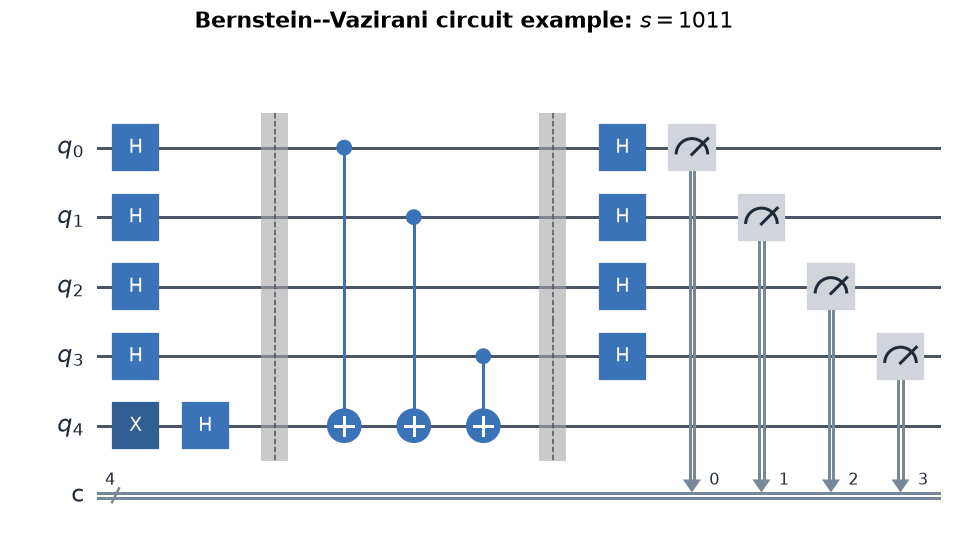

In [4]:
bv_example = create_bv_circuit("1011")
fig = circuit_drawer(
    bv_example,
    output="mpl",
    style=QISKIT_CIRCUIT_STYLE,
    fold=-1,
    cregbundle=True,
    plot_barriers=True,
    scale=0.90,
)
fig.suptitle(
    r"Bernstein--Vazirani circuit example: $s=1011$",
    fontsize=13,
    fontweight="semibold",
    y=1.02,
)
save_figure(fig, "sampler_bv_circuit_qiskit.png")
display(fig)
plt.close(fig)

### GHZ circuit

Saved: results\paper_summary\figures\sampler_ghz_circuit_qiskit.png


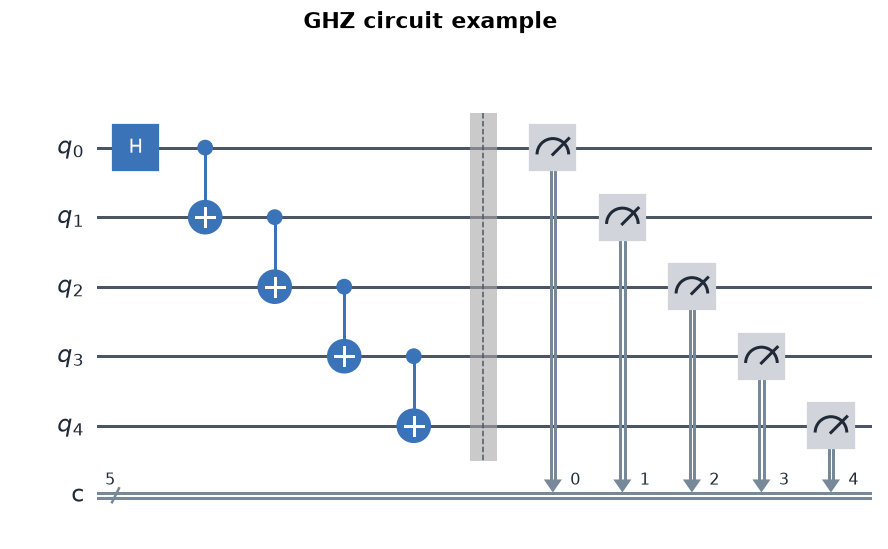

In [5]:
ghz_example = create_ghz_circuit(5)
fig = circuit_drawer(
    ghz_example,
    output="mpl",
    style=QISKIT_CIRCUIT_STYLE,
    fold=-1,
    cregbundle=True,
    plot_barriers=True,
    scale=0.90,
)
fig.suptitle(
    "GHZ circuit example",
    fontsize=13,
    fontweight="semibold",
    y=1.02,
)
save_figure(fig, "sampler_ghz_circuit_qiskit.png")
display(fig)
plt.close(fig)

### Quantum phase estimation circuit

Saved: results\paper_summary\figures\sampler_qpe_circuit_qiskit.png


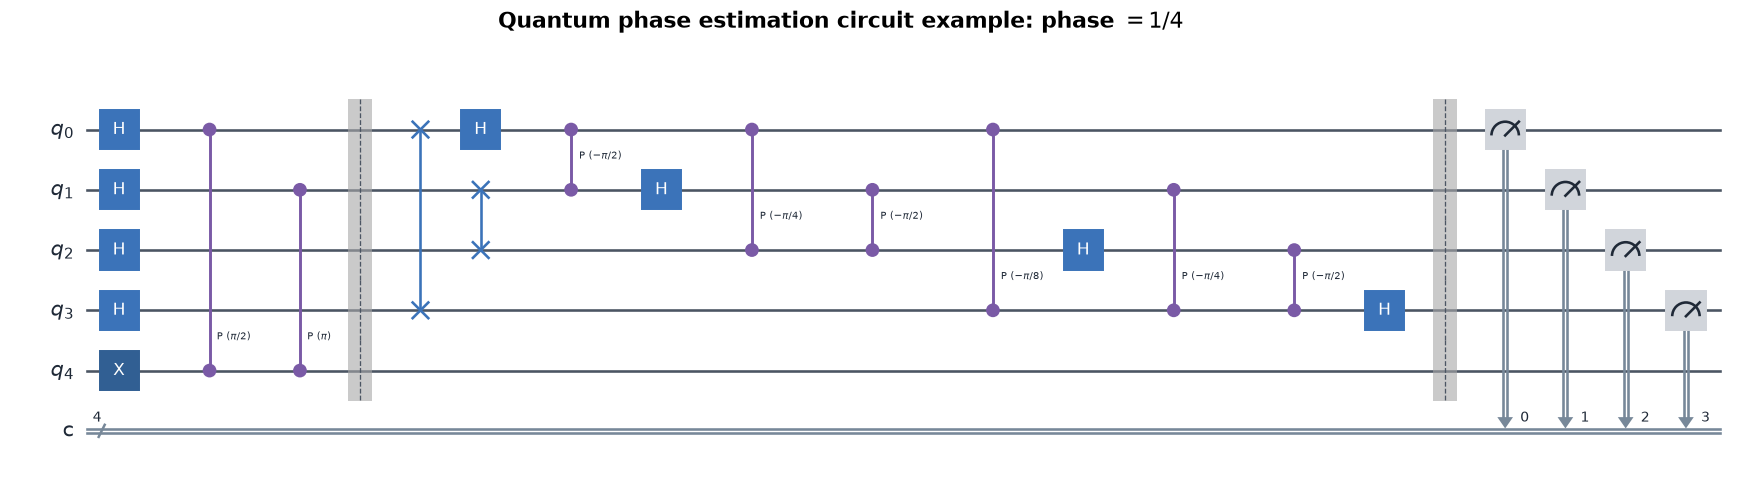

In [6]:
qpe_example = create_qpe_circuit(0.25, 4)
fig = circuit_drawer(
    qpe_example,
    output="mpl",
    style=QISKIT_CIRCUIT_STYLE,
    fold=-1,
    cregbundle=True,
    plot_barriers=True,
    scale=0.78,
)
fig.suptitle(
    r"Quantum phase estimation circuit example: phase $=1/4$",
    fontsize=13,
    fontweight="semibold",
    y=1.02,
)
save_figure(fig, "sampler_qpe_circuit_qiskit.png")
display(fig)
plt.close(fig)

### Random mirror circuit

Saved: results\paper_summary\figures\sampler_rnd_circuit_qiskit.png


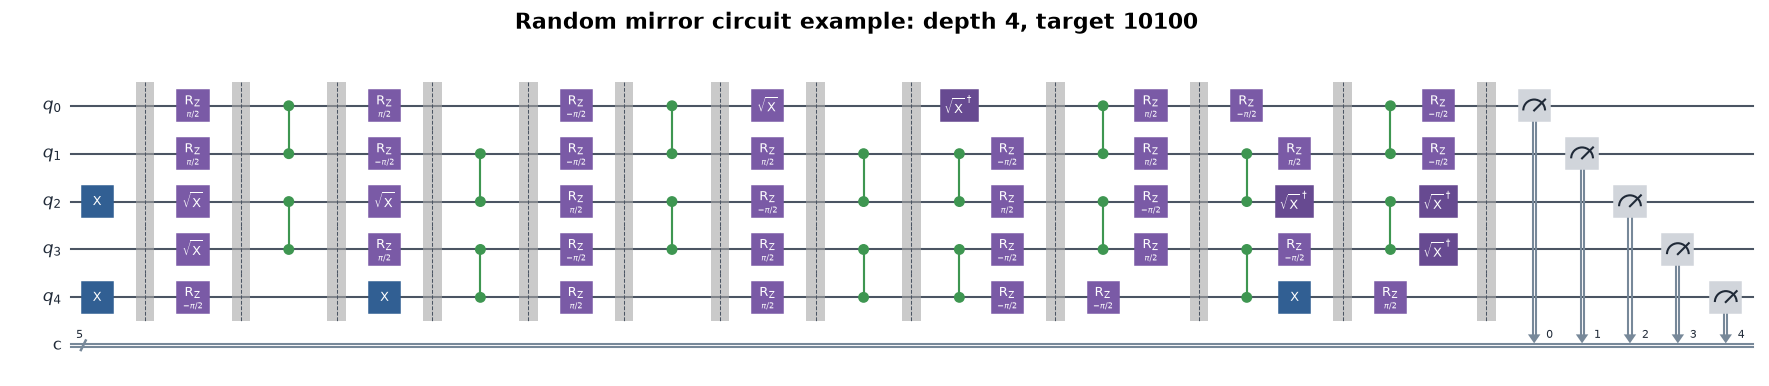

In [7]:
rnd_example, rnd_target, _ = create_native_rnd_mirror_circuit(
    n=5,
    depth=4,
    seed=4242 + 25,
    entanglement="linear",
    include_barriers=True,
    initial_state="balanced_random",
    return_target=True,
)
fig = circuit_drawer(
    rnd_example,
    output="mpl",
    style=QISKIT_CIRCUIT_STYLE,
    fold=-1,
    cregbundle=True,
    plot_barriers=True,
    scale=0.62,
)
fig.suptitle(
    f"Random mirror circuit example: depth 4, target {rnd_target}",
    fontsize=13,
    fontweight="semibold",
    y=1.02,
)
save_figure(fig, "sampler_rnd_circuit_qiskit.png")
display(fig)
plt.close(fig)

## Sampler results

Each algorithm is shown as a two-panel figure: success rate on the left and QPU time on the right.

QPU times are read directly from the available `sampler_benchmark_summary.csv` files. Rows whose `algorithms` field contains multiple workloads, such as `BV, GHZ`, are expanded so the corresponding QPU time appears in each relevant panel. Q-CTRL therefore appears in the BV, QPE, and GHZ QPU-time plots. The Q-CTRL RND summary reports QPU time as unavailable, so RND retains only the reported IBM bars.


In [8]:

def _style_axis(ax, ylabel, xlabel="Number of qubits"):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="#D9DEE5", linewidth=0.7, alpha=0.85)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def grouped_bar(
    ax,
    frame,
    *,
    x_order,
    series_order,
    value_col,
    ylabel,
    ylim=None,
    baseline=0.0,
    annotate=False,
    annotation_formatter=None,
    annotation_fontsize=7.4,
    annotation_rotation=0,
):
    x = np.arange(len(x_order), dtype=float)
    group_width = 0.68
    bar_width = group_width / max(len(series_order), 1)

    for index, series_name in enumerate(series_order):
        values = (
            frame.loc[frame["provider"].eq(series_name), ["n", value_col]]
            .drop_duplicates(subset=["n"])
            .set_index("n")[value_col]
            .reindex(x_order)
            .astype(float)
        )
        centers = x + (index - (len(series_order) - 1) / 2) * bar_width
        finite = np.isfinite(values.to_numpy())
        finite_values = values.to_numpy()[finite]
        finite_centers = centers[finite]

        heights = finite_values - baseline
        bars = ax.bar(
            finite_centers,
            heights,
            width=bar_width * 0.90,
            bottom=baseline,
            label=series_name,
            color=COLORS[series_name],
            edgecolor="#30343B",
            linewidth=0.45,
            zorder=3,
        )

        if annotate:
            for bar, value in zip(bars, finite_values):
                label = (
                    annotation_formatter(value)
                    if annotation_formatter is not None
                    else f"{value:.1f}"
                )
                y_offset = 0.012 * ((ylim[1] - ylim[0]) if ylim else max(1.0, abs(value)))
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + y_offset,
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=annotation_fontsize,
                    rotation=annotation_rotation,
                    clip_on=False,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x_order])
    # Deliberate horizontal padding prevents the first and last bars from touching the axes.
    ax.set_xlim(-0.74, len(x_order) - 0.26)
    if ylim is not None:
        ax.set_ylim(*ylim)
    _style_axis(ax, ylabel)
    return ax


def _success_label(value):
    return f"{value:.2f}" if value < 0.1 else f"{value:.1f}"


def plot_sampler_pair(algorithm, n_values):
    frame = sampler_df[
        sampler_df["algorithm"].eq(algorithm)
        & sampler_df["n"].isin(n_values)
    ].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.45))

    grouped_bar(
        axes[0],
        frame,
        x_order=n_values,
        series_order=SAMPLER_PROVIDER_ORDER,
        value_col="success_rate_percent",
        ylabel="Success rate (%)",
        ylim=(0, 106),
        annotate=True,
        annotation_formatter=_success_label,
    )
    axes[0].set_title("Success rate", fontweight="semibold")
    axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

    qpu_frame = sampler_qpu_df[
        sampler_qpu_df["algorithm"].eq(algorithm)
        & sampler_qpu_df["n"].isin(n_values)
        & sampler_qpu_df["qpu_seconds"].notna()
    ].copy()

    qpu_order = [
        provider for provider in SAMPLER_PROVIDER_ORDER
        if provider in qpu_frame["provider"].unique()
    ]

    if qpu_frame.empty:
        raise ValueError(
            f"No QPU-time rows were found for {algorithm} at {n_values}."
        )

    missing_required = []
    for provider in QPU_PROVIDERS_REQUIRED_BY_ALGORITHM[algorithm]:
        available = sorted(
            qpu_frame.loc[
                qpu_frame["provider"].eq(provider), "n"
            ].unique().tolist()
        )
        if available != list(n_values):
            missing_required.append(
                f"{provider}: expected {list(n_values)}, found {available}"
            )

    if missing_required:
        raise ValueError(
            f"Incomplete QPU summary for {algorithm}: "
            + "; ".join(missing_required)
        )

    qpu_max = max(1.0, float(qpu_frame["qpu_seconds"].max()))
    grouped_bar(
        axes[1],
        qpu_frame,
        x_order=n_values,
        series_order=qpu_order,
        value_col="qpu_seconds",
        ylabel="QPU time (s)",
        ylim=(0, qpu_max * 1.24),
        annotate=True,
        annotation_formatter=lambda value: f"{value:.1f}",
    )
    axes[1].set_title(
        "QPU time",
        fontweight="semibold",
    )

    legend_handles = [
        Patch(facecolor=COLORS[p], edgecolor="#30343B", linewidth=0.45, label=p)
        for p in SAMPLER_PROVIDER_ORDER
    ]
    fig.suptitle(f"{algorithm} sampler benchmark", fontsize=13.5, fontweight="semibold", y=0.985)
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.91),
        ncol=3,
        frameon=False,
    )
    fig.subplots_adjust(top=0.77, bottom=0.15, left=0.08, right=0.98, wspace=0.28)
    save_figure(fig, f"sampler_{algorithm.lower()}_success_and_qpu_time.png")
    plt.show()
    plt.close(fig)


### GHZ: success rate and QPU time

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


Saved: results\paper_summary\figures\sampler_ghz_success_and_qpu_time.png


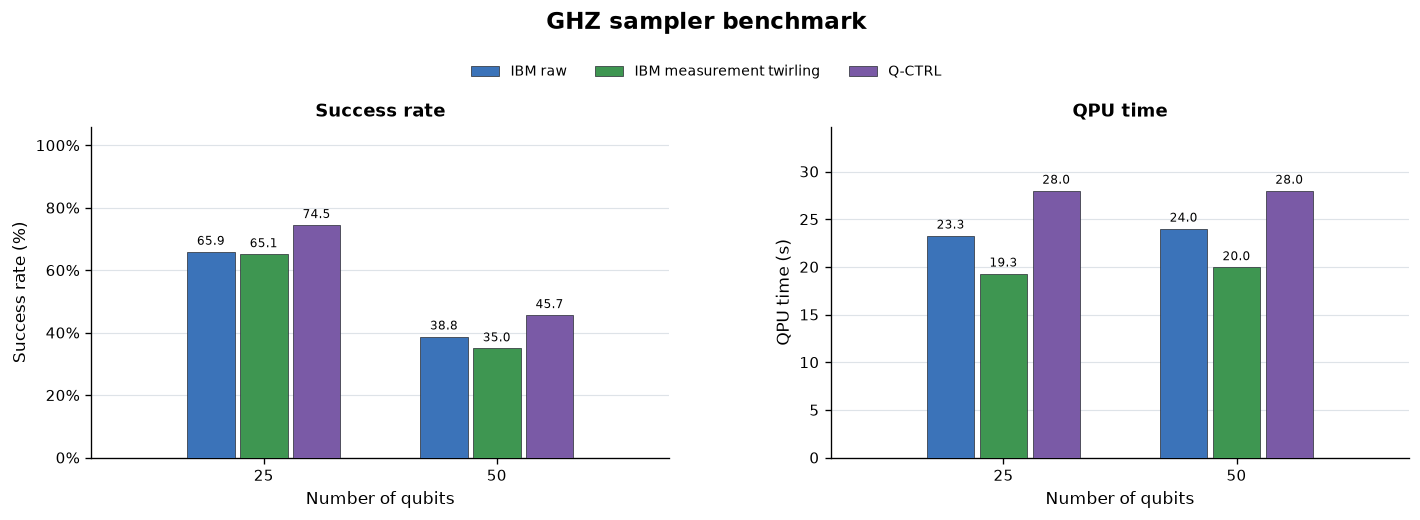

In [9]:
plot_sampler_pair('GHZ', [25, 50])

### QPE: success rate and QPU time

Saved: results\paper_summary\figures\sampler_qpe_success_and_qpu_time.png


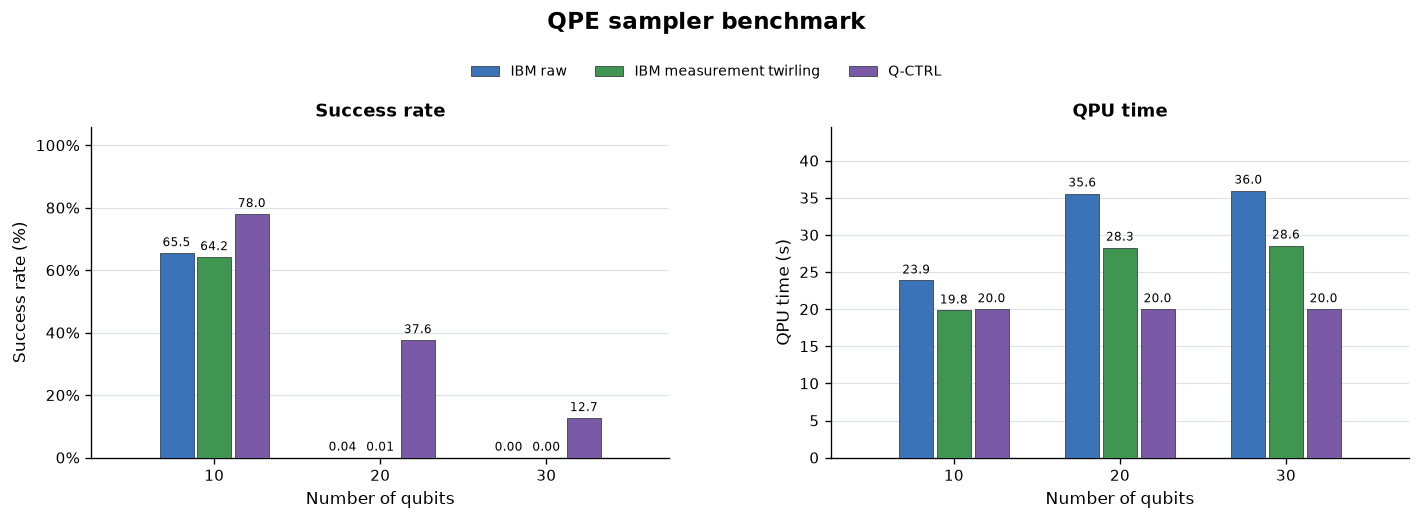

In [10]:
plot_sampler_pair('QPE', [10, 20, 30])

### BV: success rate and QPU time

Saved: results\paper_summary\figures\sampler_bv_success_and_qpu_time.png


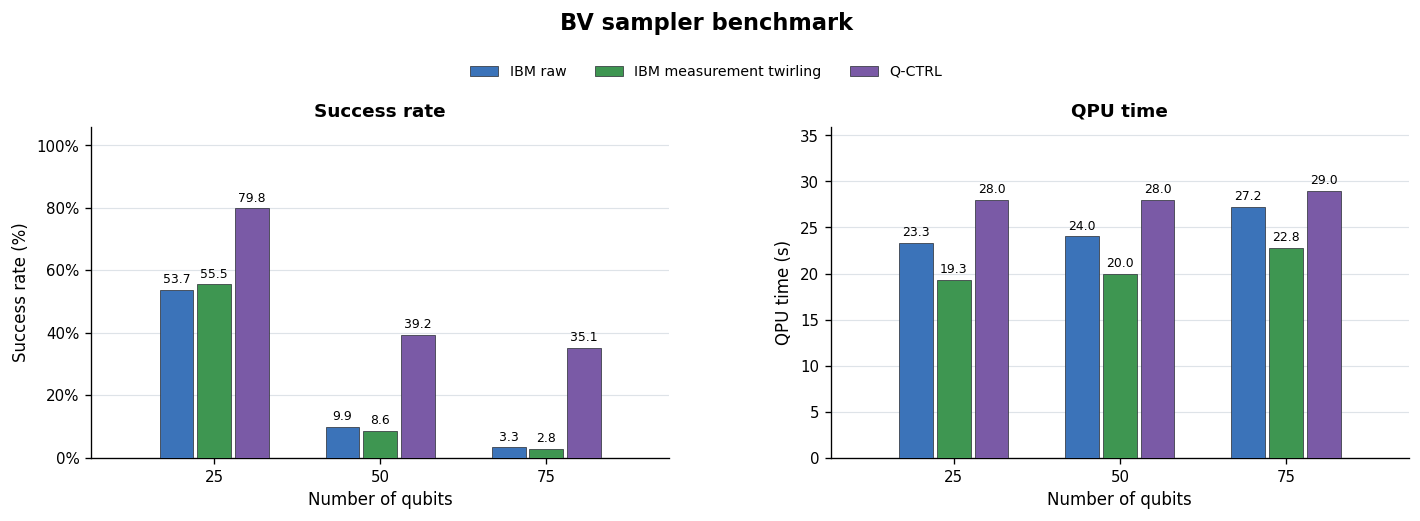

In [14]:
plot_sampler_pair('BV', [25, 50, 75])

### RND: success rate and QPU time

Saved: results\paper_summary\figures\sampler_rnd_success_and_qpu_time.png


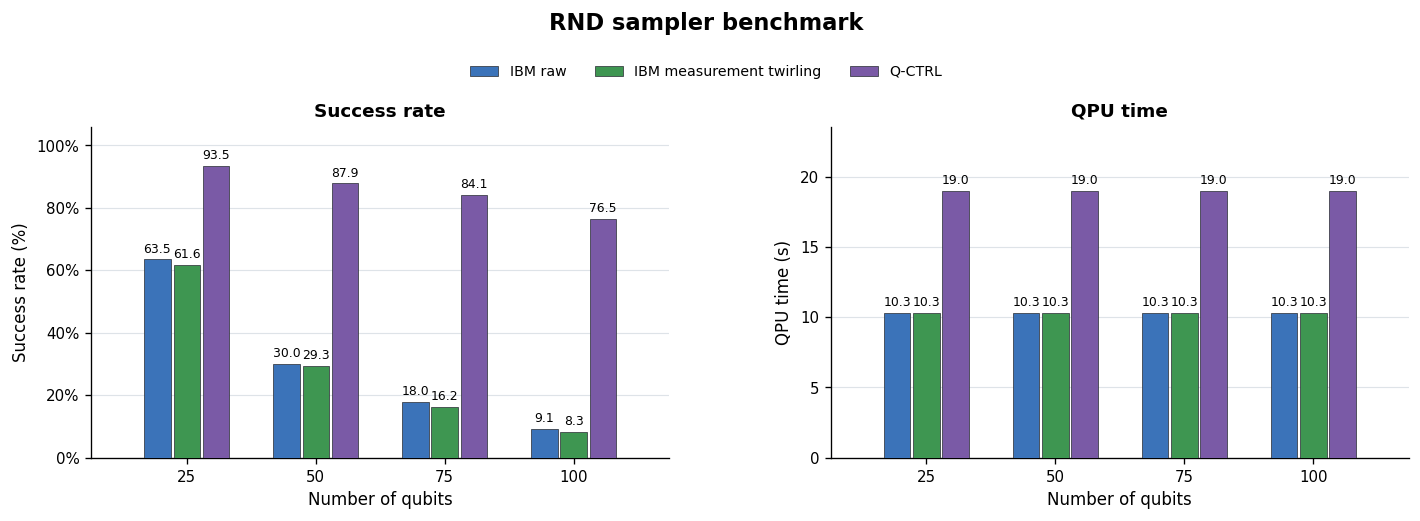

In [15]:
plot_sampler_pair('RND', [25, 50, 75, 100])

## Estimator circuit example drawn by Qiskit

The figure is generated directly from the fixed-depth TFIM circuit constructor and displayed explicitly in the notebook. A six-qubit, two-layer excerpt is shown so the even-bond and odd-bond \(R_{ZZ}\) pattern remains legible. The benchmark uses the same repeated layer with eight layers at 25, 50, and 75 qubits.


Saved: results\paper_summary\figures\estimator_tfim_circuit_example_qiskit.png


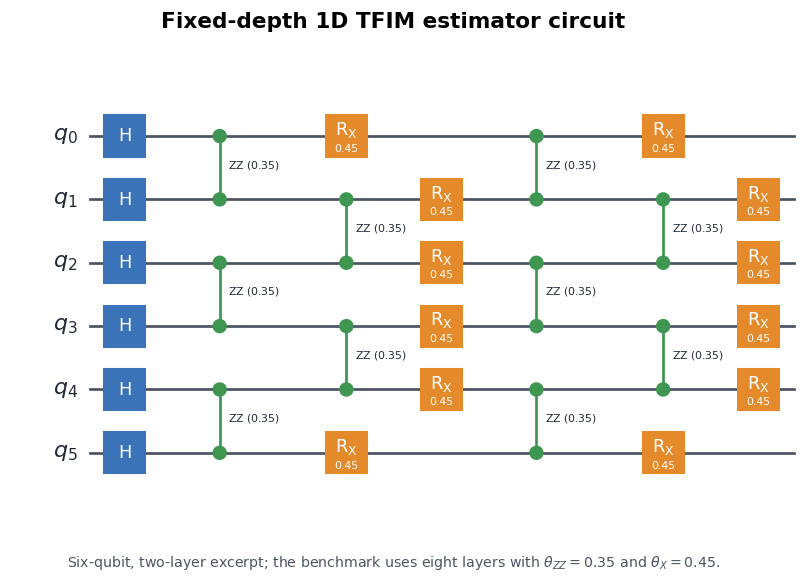

In [16]:

def create_fixed_tfim_circuit(n, layers=2, theta_zz=0.35, theta_x=0.45):
    qc = QuantumCircuit(n, name=f"TFIM_{n}q_{layers}L")
    qc.h(range(n))

    for _ in range(layers):
        for i in range(0, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)
        for i in range(1, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)
        for i in range(n):
            qc.rx(theta_x, i)

    return qc


tfim_example = create_fixed_tfim_circuit(
    n=6,
    layers=2,
    theta_zz=0.35,
    theta_x=0.45,
)

fig = circuit_drawer(
    tfim_example,
    output="mpl",
    style=QISKIT_CIRCUIT_STYLE,
    fold=-1,
    idle_wires=False,
    plot_barriers=True,
    scale=0.82,
)
fig.suptitle(
    "Fixed-depth 1D TFIM estimator circuit",
    fontsize=13,
    fontweight="semibold",
    y=1.02,
)
fig.text(
    0.5,
    -0.01,
    r"Six-qubit, two-layer excerpt; the benchmark uses eight layers with $\theta_{ZZ}=0.35$ and $\theta_X=0.45$.",
    ha="center",
    va="top",
    fontsize=8.5,
    color="#4B5563",
)
save_figure(fig, "estimator_tfim_circuit_example_qiskit.png")
display(fig)
plt.close(fig)


## Estimator results

The expected-value figures include the ideal MPS reference and numerical values on every bar. The normalized-success figures use the MPS result as the \(100\%\) reference and display the method scores on a restricted \(90\%\)–\(100\%\) axis so the differences remain visible.


In [17]:

def make_expectation_frame(observable):
    method_rows = estimator_df.loc[
        estimator_df["observable"].eq(observable),
        ["provider", "n", "expectation_value"],
    ].copy()

    mps_rows = (
        estimator_df.loc[
            estimator_df["observable"].eq(observable),
            ["n", "ideal"],
        ]
        .drop_duplicates(subset=["n"])
        .rename(columns={"ideal": "expectation_value"})
    )
    mps_rows["provider"] = "Ideal MPS"

    return pd.concat([mps_rows, method_rows], ignore_index=True)


def plot_expectation_axis(
    ax,
    observable,
    title=None,
    ylim=None,
    *,
    annotate=True,
    annotation_rotation=90,
    annotation_fontsize=6.6,
):
    frame = make_expectation_frame(observable)
    grouped_bar(
        ax,
        frame,
        x_order=[25, 50, 75],
        series_order=EXPECTATION_PROVIDER_ORDER,
        value_col="expectation_value",
        ylabel="Expectation value",
        ylim=ylim,
        annotate=annotate,
        annotation_formatter=lambda value: f"{value:.3f}",
        annotation_fontsize=annotation_fontsize,
        annotation_rotation=annotation_rotation,
    )
    if title:
        ax.set_title(title, fontweight="semibold")
    return ax


def plot_closeness_axis(
    ax,
    frame,
    title=None,
    annotate=True,
    *,
    show_reference_line=True,
):
    grouped_bar(
        ax,
        frame,
        x_order=[25, 50, 75],
        series_order=ESTIMATOR_PROVIDER_ORDER,
        value_col="closeness_percent",
        ylabel="Normalized success (%)",
        ylim=(90, 101.2),
        baseline=90.0,
        annotate=annotate,
        annotation_formatter=lambda value: f"{value:.1f}",
        annotation_fontsize=7.0,
        annotation_rotation=0,
    )
    if show_reference_line:
        ax.axhline(
            100.0,
            color=COLORS["Ideal MPS"],
            linewidth=1.0,
            linestyle="--",
            zorder=2,
        )
    if title:
        ax.set_title(title, fontweight="semibold")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    return ax


def add_estimator_legend(fig, include_mps=True, y=0.91):
    order = EXPECTATION_PROVIDER_ORDER if include_mps else ESTIMATOR_PROVIDER_ORDER
    handles = [
        Patch(facecolor=COLORS[p], edgecolor="#30343B", linewidth=0.45, label=p)
        for p in order
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=len(order),
        frameon=False,
    )


### TFIM full-chain \(H\) normalized success

Saved: results\paper_summary\figures\estimator_full_chain_normalized_success.png


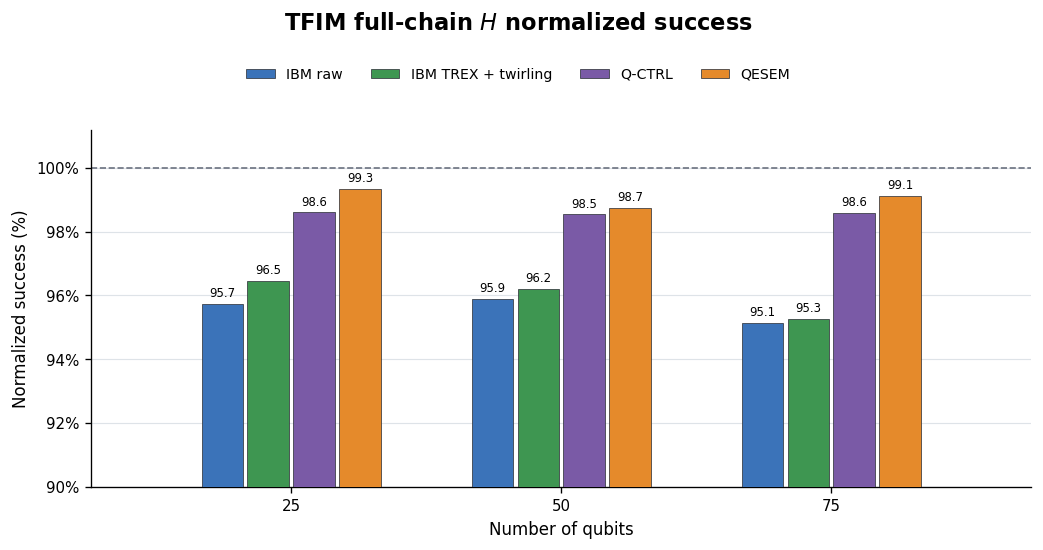

In [18]:
h_closeness_df = (
    estimator_df
    .groupby(["provider", "n"], as_index=False)["closeness_percent"]
    .mean()
)

fig, ax = plt.subplots(figsize=(8.9, 4.8))
plot_closeness_axis(ax, h_closeness_df, title=None)
fig.suptitle(r"TFIM full-chain $H$ normalized success", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=False, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_full_chain_normalized_success.png")
plt.show()
plt.close(fig)

### TFIM \(X\) expected value

Saved: results\paper_summary\figures\estimator_X_expected_value_all_methods.png


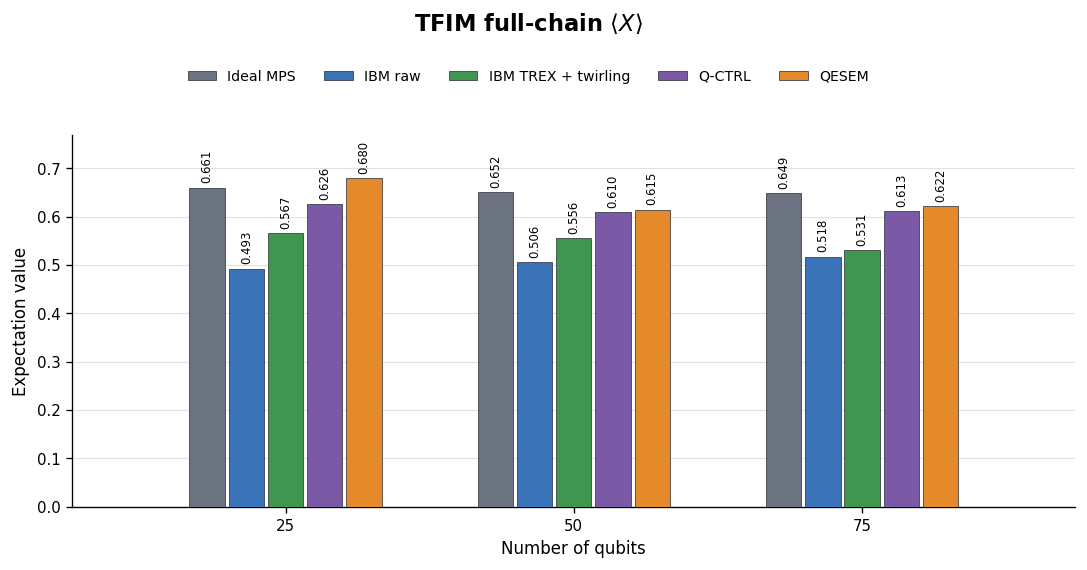

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
plot_expectation_axis(
    ax, "MX_full", title=None, ylim=(0, 0.77),
    annotate=True, annotation_rotation=90, annotation_fontsize=7.0,
)
fig.suptitle(r"TFIM full-chain $\langle X\rangle$", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=True, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_X_expected_value_all_methods.png")
plt.show()
plt.close(fig)

### TFIM \(X\) normalized success

Saved: results\paper_summary\figures\estimator_X_normalized_success.png


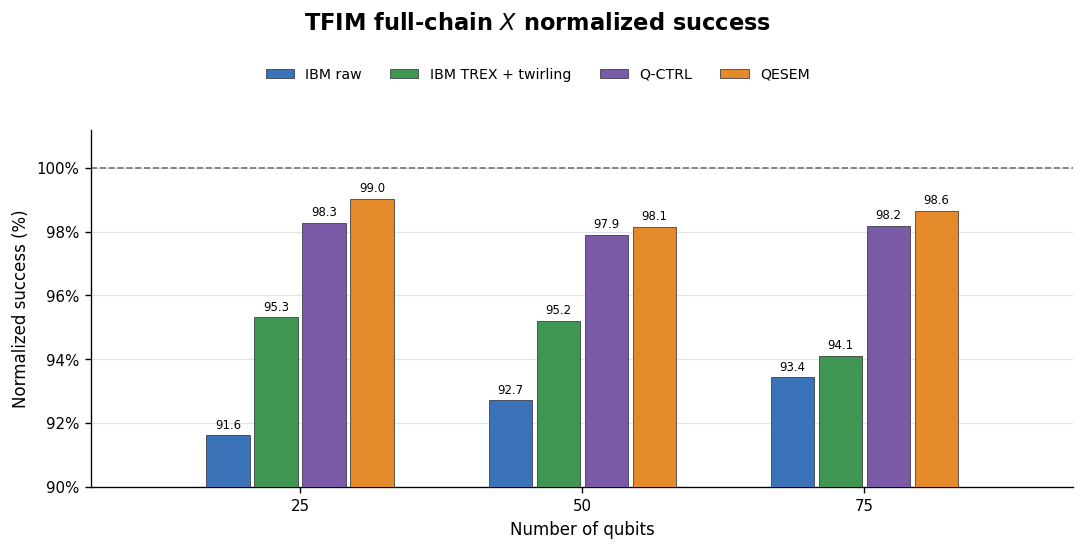

In [20]:
x_closeness_df = estimator_df.loc[
    estimator_df["observable"].eq("MX_full"),
    ["provider", "n", "closeness_percent"],
].copy()

fig, ax = plt.subplots(figsize=(9.3, 4.8))
plot_closeness_axis(ax, x_closeness_df, title=None)
fig.suptitle(r"TFIM full-chain $X$ normalized success", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=False, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_X_normalized_success.png")
plt.show()
plt.close(fig)

### TFIM \(ZZ\) expected value

Saved: results\paper_summary\figures\estimator_ZZ_expected_value_all_methods.png


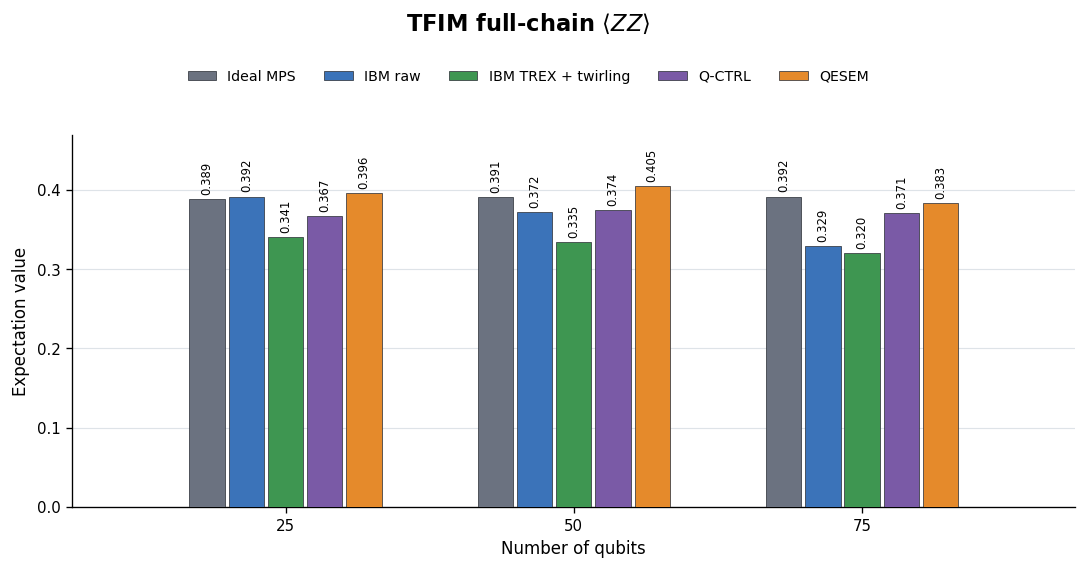

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
plot_expectation_axis(
    ax, "ZZ_full", title=None, ylim=(0, 0.47),
    annotate=True, annotation_rotation=90, annotation_fontsize=7.0,
)
fig.suptitle(r"TFIM full-chain $\langle ZZ\rangle$", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=True, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_ZZ_expected_value_all_methods.png")
plt.show()
plt.close(fig)

### TFIM \(ZZ\) normalized success

Saved: results\paper_summary\figures\estimator_ZZ_normalized_success.png


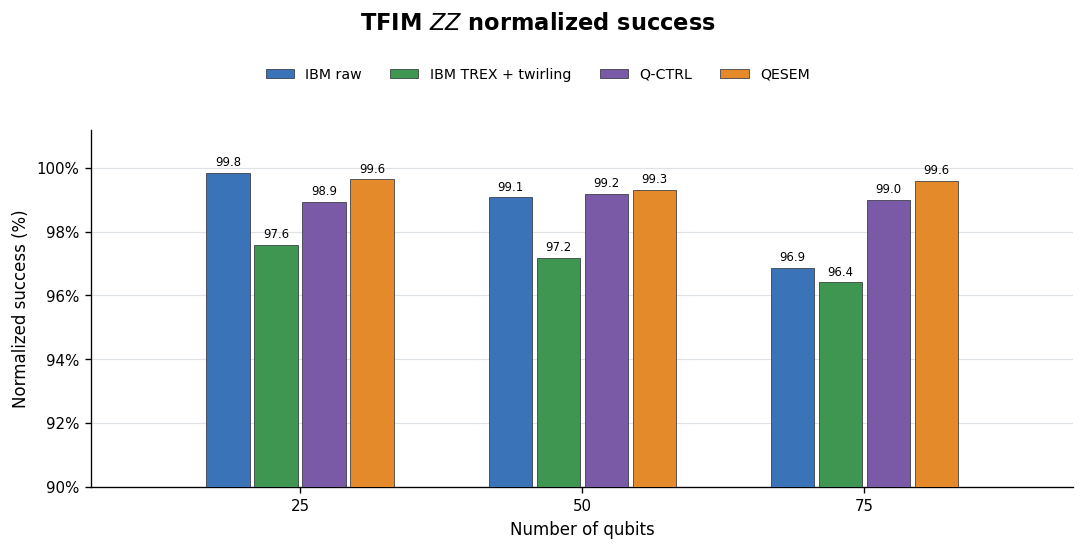

In [22]:
zz_closeness_df = estimator_df.loc[
    estimator_df["observable"].eq("ZZ_full"),
    ["provider", "n", "closeness_percent"],
].copy()

fig, ax = plt.subplots(figsize=(9.3, 4.8))
plot_closeness_axis(
    ax,
    zz_closeness_df,
    title=None,
    show_reference_line=False,
)
fig.suptitle(r"TFIM $ZZ$ normalized success", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=False, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_ZZ_normalized_success.png")
plt.show()
plt.close(fig)

### Estimator QPU time

Saved: results\paper_summary\figures\estimator_qpu_time_all_methods.png


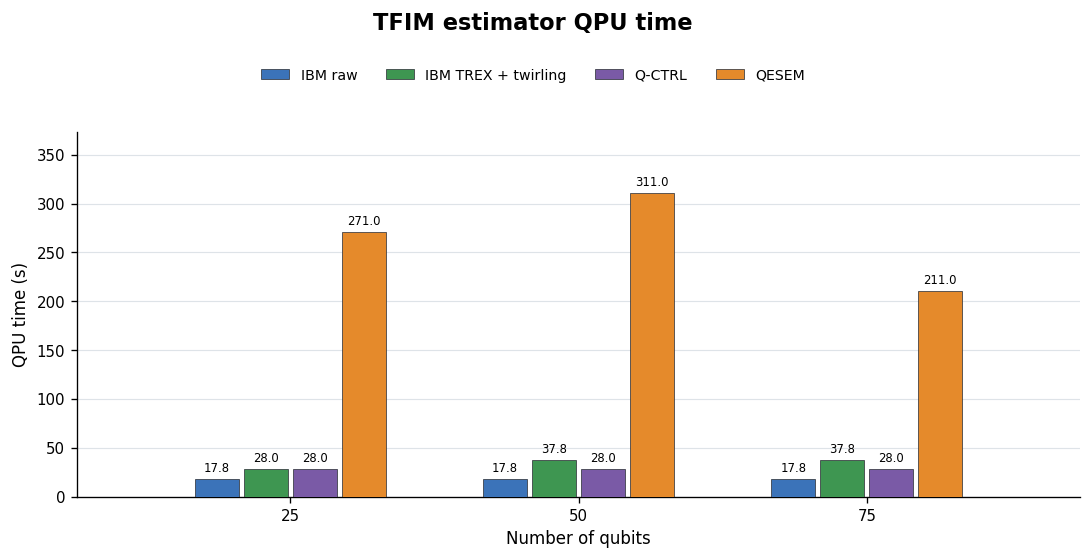

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.9))
qpu_max = float(estimator_qpu_df["qpu_seconds"].max())
grouped_bar(
    ax,
    estimator_qpu_df,
    x_order=[25, 50, 75],
    series_order=ESTIMATOR_PROVIDER_ORDER,
    value_col="qpu_seconds",
    ylabel="QPU time (s)",
    ylim=(0, qpu_max * 1.20),
    annotate=True,
    annotation_formatter=lambda value: f"{value:.1f}",
    annotation_fontsize=7.0,
)
fig.suptitle("TFIM estimator QPU time", fontsize=13.5, fontweight="semibold", y=0.985)
add_estimator_legend(fig, include_mps=False, y=0.91)
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
save_figure(fig, "estimator_qpu_time_all_methods.png")
plt.show()
plt.close(fig)

## Tables used in the figures

In [24]:
print("Sampler success data used:")
display(
    sampler_df[
        ["algorithm", "n", "provider", "success_rate_percent"]
    ]
    .sort_values(["algorithm", "n", "provider"])
    .reset_index(drop=True)
)

print("Sampler QPU times expanded from all available summary CSV files:")
display(
    sampler_qpu_df[
        ["algorithm", "n", "provider", "qpu_seconds", "qpu_time_source"]
    ]
    .sort_values(["algorithm", "n", "provider"])
    .reset_index(drop=True)
)

print("Estimator expected values and normalized success:")
display(
    estimator_df[
        [
            "observable_label",
            "n",
            "provider",
            "expectation_value",
            "ideal",
            "absolute_error",
            "closeness_percent",
        ]
    ]
    .sort_values(["observable_label", "n", "provider"])
    .reset_index(drop=True)
)

print("Estimator QPU times:")
display(
    estimator_qpu_df
    .sort_values(["n", "provider"])
    .reset_index(drop=True)
)


Sampler success data used:


,algorithm,n,provider,success_rate_percent
0,BV,25,IBM measurement twirling,55.4657
1,BV,25,IBM raw,53.6896
2,BV,25,Q-CTRL,79.7760
3,BV,50,IBM measurement twirling,8.5602
4,BV,50,IBM raw,9.9121
5,BV,50,Q-CTRL,39.1998
6,BV,75,IBM measurement twirling,2.8290
7,BV,75,IBM raw,3.2776
8,BV,75,Q-CTRL,35.1135
9,GHZ,25,IBM measurement twirling,65.1489


Sampler QPU times expanded from all available summary CSV files:


,algorithm,n,provider,qpu_seconds,qpu_time_source
0,BV,25,IBM measurement twirling,19.308443,results\sampler_benchmark\sampler_benchmark_su...
1,BV,25,IBM raw,23.289643,results\sampler_benchmark\sampler_benchmark_su...
2,BV,25,Q-CTRL,28.000000,results/sampler_benchmark-QCTRL/sampler_benchm...
3,BV,50,IBM measurement twirling,19.977826,results\sampler_benchmark\sampler_benchmark_su...
4,BV,50,IBM raw,24.022775,results\sampler_benchmark\sampler_benchmark_su...
5,BV,50,Q-CTRL,28.000000,results/sampler_benchmark-QCTRL/sampler_benchm...
6,BV,75,IBM measurement twirling,22.800634,results\sampler_benchmark\sampler_benchmark_su...
7,BV,75,IBM raw,27.206817,results\sampler_benchmark\sampler_benchmark_su...
8,BV,75,Q-CTRL,29.000000,results/sampler_benchmark-QCTRL/sampler_benchm...
9,GHZ,25,IBM measurement twirling,19.308443,results\sampler_benchmark\sampler_benchmark_su...


Estimator expected values and normalized success:


,observable_label,n,provider,expectation_value,ideal,absolute_error,closeness_percent
0,X,25,IBM TREX + twirling,0.566868,0.660634,0.093766,95.311685
1,X,25,IBM raw,0.492776,0.660634,0.167858,91.607085
2,X,25,Q-CTRL,0.626284,0.660634,0.034350,98.282499
3,X,25,QESEM,0.679887,0.660634,0.019253,99.037341
4,X,50,IBM TREX + twirling,0.555954,0.651978,0.096024,95.198807
5,X,50,IBM raw,0.506154,0.651978,0.145824,92.708775
6,X,50,Q-CTRL,0.610085,0.651978,0.041893,97.905370
7,X,50,QESEM,0.614876,0.651978,0.037102,98.144878
8,X,75,IBM TREX + twirling,0.531091,0.649093,0.118001,94.099925
9,X,75,IBM raw,0.517699,0.649093,0.131393,93.430335


Estimator QPU times:


,provider,n,qpu_seconds
0,IBM TREX + twirling,25,28.000000
1,IBM raw,25,17.823486
2,Q-CTRL,25,28.000000
3,QESEM,25,271.000000
4,IBM TREX + twirling,50,37.826296
5,IBM raw,50,17.823486
6,Q-CTRL,50,28.000000
7,QESEM,50,311.000000
8,IBM TREX + twirling,75,37.826296
9,IBM raw,75,17.823486


## Output manifest

In [23]:

print("CSV files:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("  -", path)

print("\nFigures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("  -", path)


CSV files:
  - results/paper_summary/estimator_paper_summary.csv
  - results/paper_summary/estimator_qpu_summary.csv
  - results/paper_summary/sampler_paper_summary.csv
  - results/paper_summary/sampler_qpu_summary.csv

Figures:
  - results/paper_summary/figures/estimator_X_expected_value_all_methods.png
  - results/paper_summary/figures/estimator_X_normalized_success.png
  - results/paper_summary/figures/estimator_ZZ_expected_value_all_methods.png
  - results/paper_summary/figures/estimator_ZZ_normalized_success.png
  - results/paper_summary/figures/estimator_full_chain_expected_values_X_ZZ.png
  - results/paper_summary/figures/estimator_full_chain_normalized_success.png
  - results/paper_summary/figures/estimator_qpu_time_all_methods.png
  - results/paper_summary/figures/estimator_tfim_circuit_example_qiskit.png
  - results/paper_summary/figures/sampler_bv_circuit_qiskit.png
  - results/paper_summary/figures/sampler_bv_success_and_qpu_time.png
  - results/paper_summary/figures/sample